# Análisis de juegos gratis vs juegos de pago

## Pregunta principal

¿Existen diferencias entre los juegos gratuitos y los juegos de pago en usuarios estimados, tiempo medio de juego y valoraciones?

En este notebook usamos el archivo procesado `juegos_steam_limpio_base.csv`, generado por `src/analyze_genres.py`.

## 1. Importar librerías

Usamos `pandas` para trabajar con tablas y `matplotlib` para crear gráficos.

In [1]:
# Path nos permite trabajar con rutas de archivos.
from pathlib import Path

# pandas se usa para cargar y analizar datos tabulares.
import pandas as pd

# matplotlib se usa para crear graficos.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("default")

# Formateador para mostrar numeros con punto de miles: 100.000, 200.000, etc.
def formato_miles(valor, posicion):
    return f"{valor:,.0f}".replace(",", ".")

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Cargar los datos procesados

Cargamos la tabla limpia de juegos. Esta tabla ya incluye columnas preparadas como `usuarios_estimados_aprox`, `tiempo_medio_horas`, `proporcion_positivas` y `es_gratis`.

In [2]:
# Detectamos automaticamente la carpeta del proyecto.
# Esto evita problemas si el notebook se ejecuta desde Steam_Games_2025 o desde la carpeta padre Proyectos.
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "Steam_Games_2025"]

PROJECT_ROOT = next(
    path for path in candidates
    if (path / "data" / "processed" / "juegos_steam_limpio_base.csv").exists()
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
print("Carpeta del proyecto:", PROJECT_ROOT)

# Cargamos la base limpia de juegos.
juegos = pd.read_csv(DATA_PROCESSED / "juegos_steam_limpio_base.csv")

# Mostramos las primeras filas para comprobar que se ha cargado correctamente.
juegos.head()

Carpeta del proyecto: C:\Users\djsmd\Desktop\DANI\Master Evolve\DATA_SCIENCE_ABRIL\Proyectos\Steam_Games_2025


,id_app,nombre,ano_lanzamiento,lista_generos,usuarios_estimados_rango,usuarios_estimados_aprox,tiempo_medio_minutos,tiempo_medio_horas,resenas_positivas,resenas_negativas,total_resenas,proporcion_positivas,precio,es_gratis
0,730,Counter-Strike 2,2012,"['Accion', 'Gratis']",100000000 - 200000000,150000000.0,33189,553.150000,7480813,1135108,8615921,0.868255,0.00,True
1,578080,PUBG: BATTLEGROUNDS,2017,"['Accion', 'Aventura', 'Multijugador masivo', ...",50000000 - 100000000,75000000.0,0,0.000000,1487960,1024436,2512396,0.592247,0.00,True
2,570,Dota 2,2013,"['Accion', 'Estrategia', 'Gratis']",200000000 - 500000000,350000000.0,43031,717.183333,1998462,451338,2449800,0.815765,0.00,True
3,271590,Grand Theft Auto V Legacy,2015,"['Accion', 'Aventura']",50000000 - 100000000,75000000.0,19323,322.050000,1719950,250012,1969962,0.873088,0.00,True
4,488824,Tom Clancy's Rainbow Six® Siege,2015,['Accion'],0 - 20000,10000.0,0,0.000000,312816,64201,377017,0.829713,19.99,False


### Qué representa esta tabla

Cada fila representa un juego de Steam. Para este análisis nos interesan especialmente estas columnas:

- `precio`: precio del juego.
- `es_gratis`: indica si el juego es gratuito.
- `usuarios_estimados_aprox`: punto medio del rango de usuarios estimados.
- `tiempo_medio_horas`: tiempo medio acumulado convertido a horas.
- `proporcion_positivas`: proporción de valoraciones positivas.
- `total_resenas`: número total de reseñas positivas y negativas.

## 3. Revisión rápida de los datos

Antes de comparar juegos gratis y de pago, revisamos el tamano de la tabla y comprobamos los tipos de datos principales.

In [3]:
# shape devuelve el tamano de la tabla: (filas, columnas).
print("Tamano de la tabla:", juegos.shape)

# info muestra columnas, valores no nulos y tipos de datos.
juegos.info()

Tamano de la tabla: (94948, 14)
<class 'pandas.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_app                    94948 non-null  int64  
 1   nombre                    94946 non-null  str    
 2   ano_lanzamiento           94948 non-null  int64  
 3   lista_generos             94948 non-null  str    
 4   usuarios_estimados_rango  94948 non-null  str    
 5   usuarios_estimados_aprox  94948 non-null  float64
 6   tiempo_medio_minutos      94948 non-null  int64  
 7   tiempo_medio_horas        94948 non-null  float64
 8   resenas_positivas         94948 non-null  int64  
 9   resenas_negativas         94948 non-null  int64  
 10  total_resenas             94948 non-null  int64  
 11  proporcion_positivas      72648 non-null  float64
 12  precio                    94948 non-null  float64
 13  es_gratis                 94948 non-null

### Cómo interpretar esta salida

El número de filas indica cuántos juegos tenemos en la tabla procesada. Los tipos de datos nos dicen si cada columna se está leyendo como texto, número entero, número decimal o booleano.

Para este análisis necesitamos que `es_gratis` sea una variable booleana, y que `usuarios_estimados_aprox`, `tiempo_medio_horas`, `proporcion_positivas` y `total_resenas` sean numericas.

## 4. Preparar grupos gratis vs pago

Creamos una columna textual llamada `tipo_juego` para que los gráficos y tablas sean mas fáciles de leer.

In [4]:
# Convertimos es_gratis en etiquetas legibles.
juegos["tipo_juego"] = juegos["es_gratis"].map({True: "Gratis", False: "Pago"})

# Comprobamos cuantos juegos hay en cada grupo.
juegos["tipo_juego"].value_counts()

tipo_juego
Pago      75528
Gratis    19420
Name: count, dtype: int64

### Interpretación

Esta tabla nos dice cuántos juegos gratuitos y cuántos juegos de pago hay en el dataset. Normalmente habrá muchos mas juegos de pago que juegos gratis, por eso es importante comparar medias y medianas, no solo totales.

## 5. Resumen comparativo

Agrupamos por `tipo_juego` para comparar usuarios estimados, tiempo medio y valoraciones entre juegos gratis y de pago.

In [5]:
# Para el tiempo de juego, creamos una version sin ceros.
# Muchos juegos tienen tiempo medio 0, asi que esta columna ayuda a calcular una media mas realista.
juegos["tiempo_horas_solo_si_registrado"] = juegos["tiempo_medio_horas"].where(juegos["tiempo_medio_horas"] > 0)

# Agrupamos por tipo de juego.
resumen_tipo = (
    juegos.groupby("tipo_juego", as_index=False)
    .agg(
        cantidad_juegos=("id_app", "count"),
        usuarios_estimados_media=("usuarios_estimados_aprox", "mean"),
        usuarios_estimados_mediana=("usuarios_estimados_aprox", "median"),
        tiempo_medio_horas_todos=("tiempo_medio_horas", "mean"),
        juegos_con_tiempo_registrado=("tiempo_horas_solo_si_registrado", "count"),
        tiempo_medio_horas_solo_con_tiempo=("tiempo_horas_solo_si_registrado", "mean"),
        tiempo_mediano_horas_solo_con_tiempo=("tiempo_horas_solo_si_registrado", "median"),
        proporcion_positivas_media=("proporcion_positivas", "mean"),
        total_resenas_media=("total_resenas", "mean"),
        precio_medio=("precio", "mean"),
    )
)

# Redondeamos para que la tabla sea mas legible.
columnas_enteras = ["usuarios_estimados_media", "usuarios_estimados_mediana", "total_resenas_media"]
for columna in columnas_enteras:
    resumen_tipo[columna] = resumen_tipo[columna].round(0).astype("int64")

columnas_decimales = [
    "tiempo_medio_horas_todos",
    "tiempo_medio_horas_solo_con_tiempo",
    "tiempo_mediano_horas_solo_con_tiempo",
    "proporcion_positivas_media",
    "precio_medio",
]
for columna in columnas_decimales:
    resumen_tipo[columna] = resumen_tipo[columna].round(2)

resumen_tipo

,tipo_juego,cantidad_juegos,usuarios_estimados_media,usuarios_estimados_mediana,tiempo_medio_horas_todos,juegos_con_tiempo_registrado,tiempo_medio_horas_solo_con_tiempo,tiempo_mediano_horas_solo_con_tiempo,proporcion_positivas_media,total_resenas_media,precio_medio
0,Gratis,19420,134488,0,0.77,1041,14.37,1.10,0.75,1786,0.00
1,Pago,75528,85688,10000,2.08,6978,22.49,3.92,0.75,1326,8.69


### Cómo leer esta tabla

- `cantidad_juegos`: cuántos juegos hay en cada grupo.
- `usuarios_estimados_media`: usuarios estimados medios por juego.
- `usuarios_estimados_mediana`: valor central de usuarios estimados por juego.
- `tiempo_medio_horas_todos`: media de horas incluyendo juegos con valor 0.
- `juegos_con_tiempo_registrado`: juegos cuyo tiempo medio es mayor que 0.
- `tiempo_medio_horas_solo_con_tiempo`: media de horas usando solo juegos con tiempo registrado.
- `proporcion_positivas_media`: media de valoraciones positivas.
- `precio_medio`: precio medio del grupo.

La media y la mediana pueden ser muy diferentes. Si la media es mucho mayor que la mediana, significa que hay algunos juegos con valores muy altos que empujan la media hacia arriba.

## 6. Usuarios estimados medios: gratis vs pago

Comparamos cuántos usuarios estimados tiene de media un juego gratuito frente a un juego de pago.

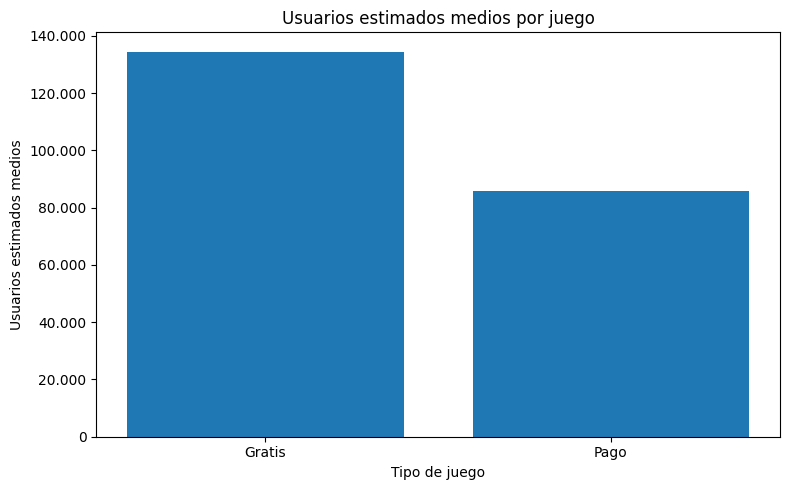

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(resumen_tipo["tipo_juego"], resumen_tipo["usuarios_estimados_media"])
ax.set_title("Usuarios estimados medios por juego")
ax.set_xlabel("Tipo de juego")
ax.set_ylabel("Usuarios estimados medios")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

### Interpretación

Este gráfico compara la popularidad media por juego. Si la barra de juegos gratis es mayor, significa que los juegos gratuitos tienen mas usuarios estimados de media. Esto puede tener sentido porque la barrera de entrada es menor: al no tener precio, mas usuarios pueden probarlos.

## 7. Tiempo medio de juego: gratis vs pago

Comparamos el tiempo medio acumulado en horas usando solo juegos con tiempo registrado mayor que 0.

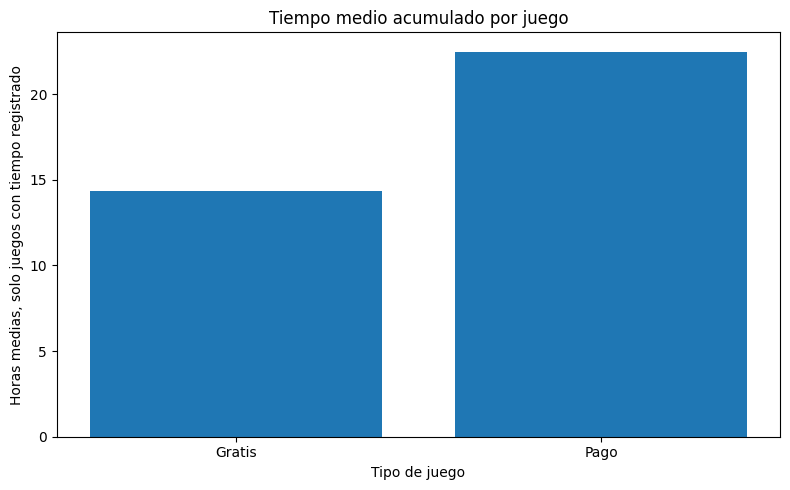

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(resumen_tipo["tipo_juego"], resumen_tipo["tiempo_medio_horas_solo_con_tiempo"])
ax.set_title("Tiempo medio acumulado por juego")
ax.set_xlabel("Tipo de juego")
ax.set_ylabel("Horas medias, solo juegos con tiempo registrado")

plt.tight_layout()
plt.show()

### Interpretación

Este gráfico ayuda a ver si los juegos gratuitos no solo llegan a mas usuarios, sino si también generan mas tiempo de juego. Al usar solo juegos con tiempo registrado, evitamos que los muchos valores 0 oculten diferencias reales.

## 8. Valoraciones positivas: gratis vs pago

Comparamos la proporción media de valoraciones positivas entre juegos gratis y juegos de pago.

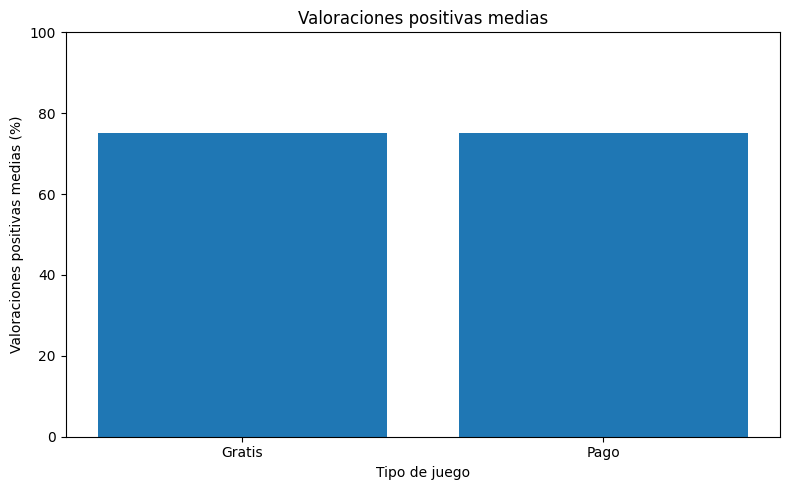

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(resumen_tipo["tipo_juego"], resumen_tipo["proporcion_positivas_media"] * 100)
ax.set_title("Valoraciones positivas medias")
ax.set_xlabel("Tipo de juego")
ax.set_ylabel("Valoraciones positivas medias (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Interpretación

Este gráfico permite comprobar si tener mas usuarios implica también mejores valoraciones. Puede ocurrir que los juegos gratuitos tengan mas alcance, pero no necesariamente mejores opiniones medias.

## 9. Conclusiones provisionales

- La comparacion entre juegos gratis y de pago debe hacerse con medias o medianas, no con totales, porque hay muchos mas juegos de un tipo que de otro.
- Los juegos gratuitos suelen tener una barrera de entrada menor, por lo que pueden acumular mas usuarios estimados medios.
- Para el tiempo de juego conviene mirar solo juegos con tiempo registrado, porque muchos juegos tienen valor 0 en el dataset.
- Las valoraciones positivas ayudan a distinguir popularidad de satisfacción: un juego puede tener muchos usuarios, pero no necesariamente mejores valoraciones.

Estas conclusiones deben confirmarse mirando los valores concretos de `resumen_tipo`, no solo los gráficos.